# Pregunta 2 — Parte a

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

archivo = Path("Datos Tarea 1 2026.xlsx")
if not archivo.exists():
    archivo = Path("Comportamiento Mecánico de Materiales") / "Tarea 1" / archivo

datos = pd.read_excel(archivo, usecols="A,C,E")
datos.columns = ["R_a0", "U_e_eV", "U_n_eV"]
datos = datos.apply(pd.to_numeric, errors="coerce").dropna()
datos = datos.sort_values("R_a0").reset_index(drop=True)

a0_nm = 0.0529
eV_por_nm_a_nN = 0.1602
R = datos["R_a0"].to_numpy() * a0_nm
assert len(R) >= 3 and np.all(np.diff(R) > 0)
datos["R_nm"] = R
for tipo in ("e", "n"):
    U = datos[f"U_{tipo}_eV"].to_numpy()
    datos[f"F_{tipo}_nN"] = -np.gradient(U, R, edge_order=2) * eV_por_nm_a_nN

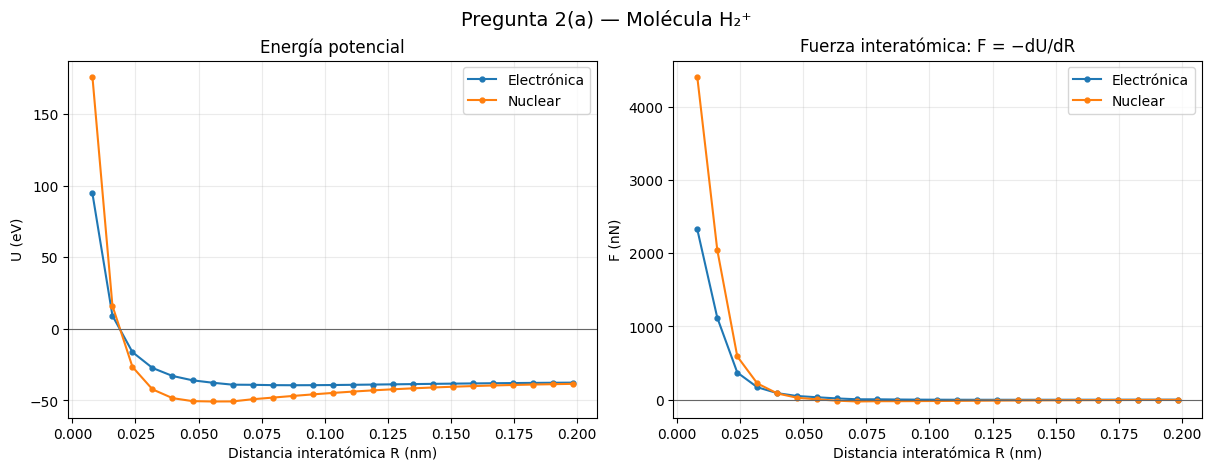

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
for tipo, nombre, color in (("e", "Electrónica", "tab:blue"),
                            ("n", "Nuclear", "tab:orange")):
    axes[0].plot(R, datos[f"U_{tipo}_eV"], "o-", ms=3.5, label=nombre, color=color)
    axes[1].plot(R, datos[f"F_{tipo}_nN"], "o-", ms=3.5, label=nombre, color=color)

axes[0].set(title="Energía potencial", ylabel="U (eV)")
axes[1].set(title="Fuerza interatómica: F = −dU/dR", ylabel="F (nN)")
for ax in axes:
    ax.set_xlabel("Distancia interatómica R (nm)")
    ax.axhline(0, color="0.4", lw=0.8)
    ax.grid(alpha=0.25)
    ax.legend()
fig.suptitle("Pregunta 2(a) — Molécula H₂⁺", fontsize=14)
plt.show()

La repulsión a distancias pequeñas domina la escala del gráfico de fuerza. El siguiente acercamiento permite distinguir la región atractiva de ambas curvas. Los puntos representan los datos y las fuerzas calculadas; las líneas solo los conectan, sin suavizado.

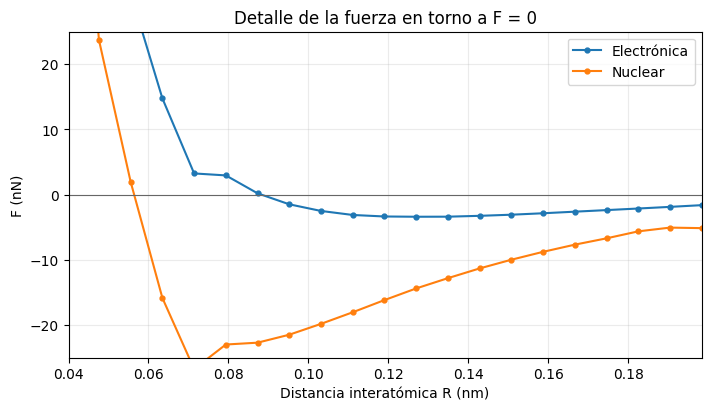

In [3]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for tipo, nombre, color in (("e", "Electrónica", "tab:blue"),
                            ("n", "Nuclear", "tab:orange")):
    ax.plot(R, datos[f"F_{tipo}_nN"], "o-", ms=3.5, label=nombre, color=color)
ax.set(xlim=(0.04, R.max()), ylim=(-25, 25),
       xlabel="Distancia interatómica R (nm)", ylabel="F (nN)",
       title="Detalle de la fuerza en torno a F = 0")
ax.axhline(0, color="0.4", lw=0.8)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Parte b

In [4]:
resultados = []
for tipo, nombre in (("e", "Electrónica"), ("n", "Nuclear")):
    i = datos[f"U_{tipo}_eV"].idxmin()
    resultados.append([nombre, datos.loc[i, "R_nm"], datos.loc[i, f"U_{tipo}_eV"]])

parte_b = pd.DataFrame(resultados, columns=["Curva", "R0 (nm)", "U0 (eV)"])
print(parte_b.to_string(index=False))

      Curva  R0 (nm)  U0 (eV)
Electrónica 0.087285  -39.411
    Nuclear 0.055545  -50.769


## Parte c

In [5]:
h = R[1] - R[0]
resultados = []

for tipo, nombre in (("e", "Electrónica"), ("n", "Nuclear")):
    U = datos[f"U_{tipo}_eV"].to_numpy()
    i = U.argmin()
    R0 = R[i]
    d2U = (-U[i+2] + 16*U[i+1] - 30*U[i] + 16*U[i-1] - U[i-2]) / (12*h**2)
    K = d2U / (9*R0) * 0.1602
    resultados.append([nombre, K])

parte_c = pd.DataFrame(resultados, columns=["Curva", "K (GPa)"])
print(parte_c.to_string(index=False))

      Curva    K (GPa)
Electrónica 326.310898
    Nuclear 332.518632


## Parte d

In [6]:
resultados = []

for tipo, nombre in (("e", "Electrónica"), ("n", "Nuclear")):
    i = datos[f"U_{tipo}_eV"].idxmin()
    R0 = R[i]
    F = datos[f"F_{tipo}_nN"].to_numpy()
    F_max = -F[R > R0].min()
    sigma = F_max / R0**2 * 1000
    resultados.append([nombre, sigma])

parte_d = pd.DataFrame(resultados, columns=["Curva", "Esfuerzo de ruptura (MPa)"])
print(parte_d.to_string(index=False))

      Curva  Esfuerzo de ruptura (MPa)
Electrónica               4.438653e+05
    Nuclear               8.663904e+06
